In [124]:
import numpy as np
from scipy.integrate import odeint,solve_ivp
import matplotlib.pyplot as plt
from scipy import interpolate
from functools import partial
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FuncFormatter
import matplotlib
from numpy import exp
import pandas as pd
%matplotlib inline
from ipywidgets import interact
import math

In [125]:
###Comparing pituitary dividing vs. nondividing:

In [126]:
##Model A:
#Simulating for pituitary dividing:

In [127]:
def get5eqsparams(timescale='day'):
    #parameters are from the paper Mathematical modeling of the hypothalamic-pituitary-adrenal gland (HPA) axis, including hippocampal mechanisms.
    #Andersen M1, Vinther F, Ottesen JT.
    
    a1=1/5 #[1/min]
    a2=1/30 #[1/min]
    a3=1/90 #[1/min]

    #mitosis every ** days according to Nolan et al    
    aP=1/15/(60*24)
    
    # turnover of ** days according to Kataoka et al
    aA=1/15/(60*24)

    
    #We normalize all means to 1, we therefore get
    b1=a1;b2=a2;b3=a3;bA=aA;bP=aP;
    
    res=np.array([a1,a2,a3,aA,aP,b1,b2,b3,bA,bP])
    
    if timescale=='hour':
        res=60*res
    elif timescale=='day':
        res=24*60*res
    else:
        raise ValueError('timescale {} is not defined'.format(timescale))
    
    return res


def class_5(y,t,timescale='day',u_func = lambda t:1,crh_func = lambda t:1):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_/x3_-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[3]= P_*(bP_*x1_-aP_)#Pituitary cells   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy


def class_4(y,t,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x2_,x3_,P_,A_]=y
    dy=np.empty(4)
    #dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[0]= (b2_*P_*u_func(t))/x3_-a2_*x2_ #ACTH#hormone
    dy[1]= b3_*x2_*A_-a3_*x3_ #Cortisol#metabolite
    dy[2]= 0   
    dy[3]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy


def class_3(y,t,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x2_,x3_,A_]=y
    dy=np.empty(3)
    dy[0]= u_func(t)-a2_*x2_*x3_ #ACTH#metabolite
    dy[1]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[2]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

def class_2(y,t,timescale='day',u_func = lambda t:1):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x3_,A_]=y
    dy=np.empty(2)
    dy[0]= b3_*u_func(t)*A_-a3_*x3_ #Cortisol#metabolite 
    dy[1]= 0 #Adrenal cells
    return dy

def class_1(y,t,timescale='day',u_func = lambda t:1):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x3_]=y
    dy=np.empty(1)
    dy[0]= u_func(t)-a3_*x3_ #Cortisol#metabolite 
    #dy[0]= b3_*u_func(t)*A_-a3_*x3_ #Cortisol#metabolite 
    #dy[1]= 0 #Adrenal cells
    return dy

In [128]:
##analytic solutions for class 1 and class 2

In [129]:
def class_1_sol(t, y0, timescale='day', u_func=lambda t: 1):

    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_] = get5eqsparams(timescale)
    [x3_0] = y0
    u_vec = np.array([u_func(t) for t in t])

    return u_vec/a3_ + (x3_0 - u_vec/a3_)*exp(-a3_*t)


def class_2_sol(t, y0, timescale='day', u_func=lambda t: 1):

    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_] = get5eqsparams(timescale)
    [x3_0, A_0] = y0
    u_vec = np.array([u_func(t) for t in t])
    
    return b3_*u_vec*A_0/a3_ + (x3_0 - b3_*u_vec*A_0/a3_)*exp(-a3_*t)

In [130]:
#simulating stress as step function:
def stress_input_short_1(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_1(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

In [131]:
#For Tomer: #class 1 hormone levels:

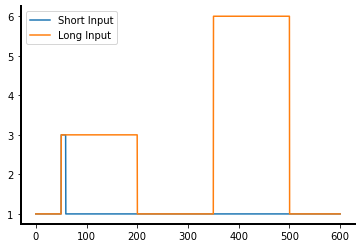

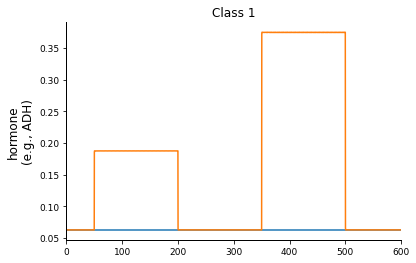

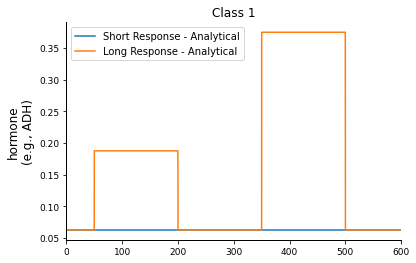

In [132]:
t_recovery = np.linspace(0, 600, 3000)
[a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_] = get5eqsparams("day")
y0 = 1 / a3_

sol_short_1 = solve_ivp(
    fun=lambda t, y: class_1(y, t, timescale='day', u_func=stress_input_short_1),
    t_span=[t_recovery[0], t_recovery[-1]],
    y0=[y0],
)
sol_long_1 = solve_ivp(
    fun=lambda t, y: class_1(y, t, timescale='day', u_func=stress_input_long_1),
    t_span=[t_recovery[0], t_recovery[-1]],
    y0=[y0],
)

plt.plot(t_recovery, [stress_input_short_1(t) for t in t_recovery], label='Short Input')
plt.plot(t_recovery, [stress_input_long_1(t) for t in t_recovery], label='Long Input')
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

plt.plot(sol_short_1.t, sol_short_1.y.T)
plt.plot(sol_long_1.t, sol_long_1.y.T)
plt.title("Class 1")
#plt.legend()
plt.xlim(0,600)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone\n(e.g., ADH)',fontsize=12)
plt.show()

plt.plot(sol_short_1.t, class_1_sol(sol_short_1.t, [y0], timescale='day', u_func=stress_input_short_1), label="Short Response - Analytical")
plt.plot(sol_long_1.t, class_1_sol(sol_long_1.t, [y0], timescale='day', u_func=stress_input_long_1), label="Long Response - Analytical")
plt.title("Class 1")
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlim(0,600)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone\n(e.g., ADH)',fontsize=12)
plt.show()

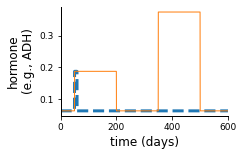

In [133]:
def custom_y(x):
    if x < 50:
        return 1/16
    elif 50 <= x < 59:
        return 3/16
    else:
        return 1/16
    
def long_input(z):
    if 0<z<=50:
        return 1/16
    elif 50<z<=200:
        return 3/16
    elif 200<z<=350:
        return 1/16
    elif 350<z<=500:
        return 6/16
    else:
        return 1/16 
   
# Generate x values from 0 to 100 (or any range you prefer)
x_values = np.linspace(0, 600, 3000)
z_values = np.linspace(0, 600, 3000)

# Calculate corresponding y values using the custom function
y_values = np.array([custom_y(x) for x in x_values])
y_long = np.array([long_input(z) for z in z_values])

plt.figure(figsize=(3,2))

# Plot the curve
plt.plot(x_values, y_values,'--',linewidth='3')
plt.plot(x_values, y_long, linewidth='1' )

# Show the plot


# Add labels and title

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlim(0,600)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('time (days)',fontsize=12)
plt.ylabel('hormone\n(e.g., ADH)',fontsize=12)
plt.savefig("class 1 hormone pulse simulation.svg", transparent=True)
plt.show()


In [134]:
#simulating stress as step function:
def stress_input_short_2(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
    # if 50<t<=80:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_2(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

In [135]:
#For Tomer: ####class 2 hormone levels

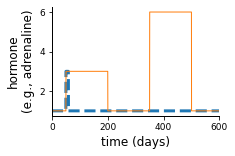

In [136]:
t_recovery = np.linspace(0, 600, 3000)
sol_short_2 = solve_ivp(
    fun=lambda t, y: class_2(y, t, timescale='day', u_func=stress_input_short_2),
    t_span=[t_recovery[0], t_recovery[-1]],
    y0=[1, 1],
    method='Radau',
    t_eval=t_recovery
)
sol_long_2 = solve_ivp(
    fun=lambda t, y: class_2(y, t, timescale='day', u_func=stress_input_long_2),
    t_span=[t_recovery[0], t_recovery[-1]],
    y0=[1, 1],
)

#plt.plot(t_recovery, [stress_input_short_2(t) for t in t_recovery], label='Short Input')
#plt.plot(t_recovery, [stress_input_long_2(t) for t in t_recovery], label='Long Input')
#plt.legend()
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.show()

#plt.plot(sol_short_2.t, sol_short_2.y[0], label="Short Response - Simulation")
#plt.plot(sol_long_2.t, sol_long_2.y[0], label="Long Response - Simulation")
#plt.title("Class 2")
#plt.legend()
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.show()

plt.figure(figsize=(3,2))
plt.plot(sol_short_2.t, class_2_sol(sol_short_2.t, [1, 1], timescale='day', u_func=stress_input_short_2),'--',linewidth='3')
plt.plot(sol_long_2.t, class_2_sol(sol_long_2.t, [1, 1], timescale='day', u_func=stress_input_long_2),linewidth='1')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlim(0,600)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('time (days)',fontsize=12)
plt.ylabel('hormone\n(e.g., adrenaline)',fontsize=12)
plt.savefig("class 2 hormone pulse simulation.svg", transparent=True)
plt.show()

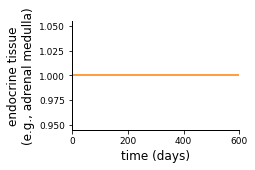

In [137]:
#plotting gland mass dynamics class 2:

x_values = np.linspace(0, 600, 1000)  
y_values = np.ones_like(x_values)  

plt.figure(figsize=(3,2))
plt.plot(x_values, y_values, color=(1, 0.5, 0))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlim(0,600)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('time (days)',fontsize=12)
plt.ylabel('endocrine tissue\n(e.g., adrenal medulla)',fontsize=12)
plt.savefig("class 2 gland mass dynamics.svg", transparent=True)
plt.show()



In [138]:
#simulating stress as step function:
def stress_input_short_1(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_1(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

In [139]:
#For Tomer: #class 1 hormone levels:

In [140]:
#simulating stress as step function:
def stress_input_short_2(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_2(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

In [141]:
#For Tomer: ####class 2 hormone levels

In [142]:
#simulating stress as step function:
def stress_input_short_3(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_3(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

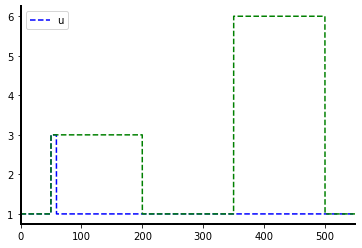

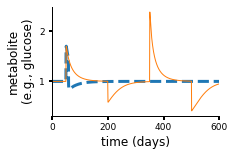

In [143]:
#class 3 metabolite levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_3(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_3(x) for x in t_recovery],'--',color='green')
plt.xlim(0,550)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_short_3),[1,(1/48),(1/48)],t_recovery)
sol_slow_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_long_3),[1,(1/48),(1/48)],t_recovery)
plt.plot(t_recovery,sol_fast_class_3[:,0],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_3[:,0],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.ylabel('metabolite\n(e.g., glucose)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.savefig("class 3 metabolite pulse simulation.svg", transparent=True)

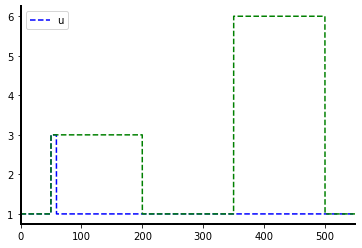

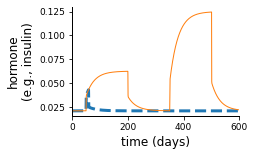

In [144]:
#class 3 hormone levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_3(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_3(x) for x in t_recovery],'--',color='green')
plt.xlim(0,550)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_short_3),[1,(1/48),(1/48)],t_recovery)
sol_slow_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_long_3),[1,(1/48),(1/48)],t_recovery)
plt.plot(t_recovery,sol_fast_class_3[:,1],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_3[:,1],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone\n(e.g., insulin)',fontsize=12)
plt.savefig("class 3 hormone pulse simulation.svg", transparent=True)

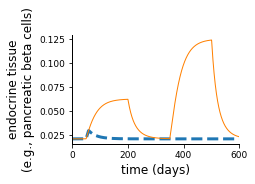

In [145]:
#class 3 gland mass dynamics:
plt.figure(figsize=(3,2))
plt.plot(t_recovery,sol_fast_class_3[:,2],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_3[:,2],linewidth='1',color=(1, 0.5, 0))
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('endocrine tissue\n(e.g., pancreatic beta cells)',fontsize=12)
plt.savefig("class 3 gland mass dynamics.svg", transparent=True)

In [146]:
#simulating stress as step function:
def stress_input_short_4(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_4(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

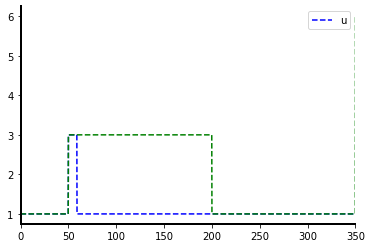

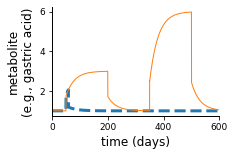

In [147]:
#class 4 metabolite levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_4(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_4(x) for x in t_recovery],'--',color='green')
plt.xlim(0,350)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = stress_input_short_3),np.ones(4),t_recovery)
sol_slow_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = stress_input_long_3),np.ones(4),t_recovery)
plt.plot(t_recovery,sol_fast_class_4[:,1],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_4[:,1],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('metabolite\n(e.g., gastric acid)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.savefig("class 4 metabolite pulse simulation.svg", transparent=True)

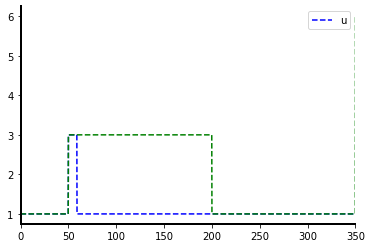

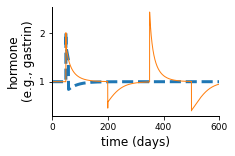

In [148]:
#class 4 hormone levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_4(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_4(x) for x in t_recovery],'--',color='green')
plt.xlim(0,350)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = stress_input_short_3),np.ones(4),t_recovery)
sol_slow_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = stress_input_long_3),np.ones(4),t_recovery)
plt.plot(t_recovery,sol_fast_class_4[:,0],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_4[:,0],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.ylabel('hormone\n(e.g., gastrin)',fontsize=12)
plt.savefig("class 4 hormone pulse simulation.svg", transparent=True)

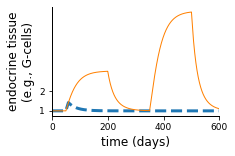

In [149]:
#class 4 gland mass dynamics:
plt.figure(figsize=(3,2))
plt.plot(t_recovery,sol_fast_class_4[:,3],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_4[:,3],linewidth='1',color=(1, 0.5, 0))
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.ylabel('endocrine tissue\n(e.g., G-cells)',fontsize=12)
plt.savefig("class 4 gland dynamics.svg", transparent=True)

In [150]:
#simulating stress as step function:
def stress_input_short_5(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_5(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

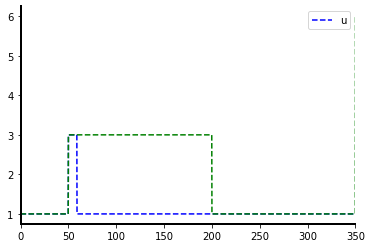

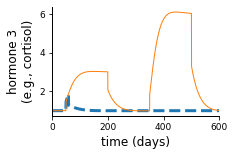

In [151]:
#class 5 end hormone levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_5(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_5(x) for x in t_recovery],'--',color='green')
plt.xlim(0,350)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_short_5),np.ones(5),t_recovery)
sol_slow_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_long_5),np.ones(5),t_recovery)
plt.plot(t_recovery,sol_fast_class_5[:,2],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_5[:,2],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.ylabel('hormone 3\n(e.g., cortisol)',fontsize=12)
plt.savefig("class 5 hormone 3 pulse simulation.svg", transparent=True)

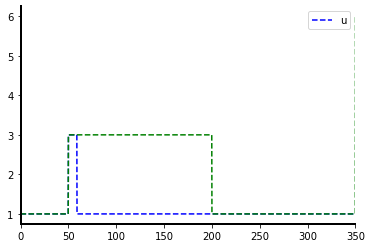

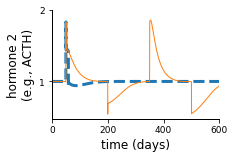

In [152]:
#class 5 middle hormone levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_5(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_5(x) for x in t_recovery],'--',color='green')
plt.xlim(0,350)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_short_5),np.ones(5),t_recovery)
sol_slow_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_long_5),np.ones(5),t_recovery)
plt.plot(t_recovery,sol_fast_class_5[:,1],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_5[:,1],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2],fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.ylabel('hormone 2\n(e.g., ACTH)',fontsize=12)
plt.savefig("class 5 hormone 2 pulse simulation.svg", transparent=True)

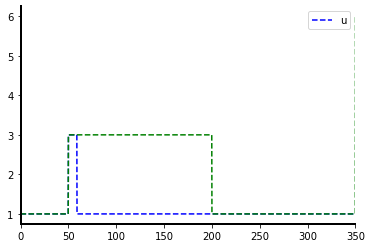

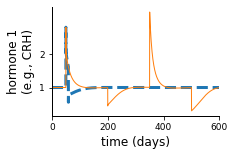

In [153]:
#class 5 "first" hormone levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_5(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_5(x) for x in t_recovery],'--',color='green')
plt.xlim(0,350)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_short_5),np.ones(5),t_recovery)
sol_slow_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_long_5),np.ones(5),t_recovery)
plt.plot(t_recovery,sol_fast_class_5[:,0],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_5[:,0],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
#plt.gca().xaxis.set_major_formatter(FuncFormatter(format_float))
#plt.gca().yaxis.set_major_formatter(FuncFormatter(format_float))
plt.ylabel('hormone 1\n(e.g., CRH)',fontsize=12)
plt.savefig("class 5 hormone 1 pulse simulation.svg", transparent=True)

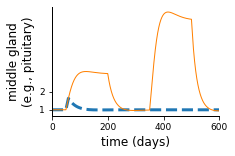

In [154]:
#class 5 middle gland dynamics:
plt.figure(figsize=(3,2))
plt.plot(t_recovery,sol_fast_class_5[:,3],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_5[:,3],linewidth='1', color=(1, 0.5, 0))
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
#plt.gca().xaxis.set_major_formatter(FuncFormatter(format_float))
#plt.gca().yaxis.set_major_formatter(FuncFormatter(format_float))
plt.ylabel('middle gland\n(e.g., pituitary)',fontsize=12)
plt.savefig("class 5 middle gland dynamics.svg", transparent=True)

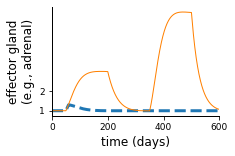

In [155]:
#class 5 end gland dynamics:
plt.figure(figsize=(3,2))
plt.plot(t_recovery,sol_fast_class_5[:,4],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_5[:,4],linewidth='1',color=(1, 0.5, 0))
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
#plt.gca().xaxis.set_major_formatter(FuncFormatter(format_float))
#plt.gca().yaxis.set_major_formatter(FuncFormatter(format_float))
plt.ylabel('effector gland\n(e.g., adrenal)',fontsize=12)
plt.savefig("class 5 effector gland dynamics.svg", transparent=True)

In [156]:
#########################21.12.23##########################

In [157]:
#######class 3##########

In [158]:
def class_3_param_a2(y,t,a2_=1,timescale='day',u_func = stress_input_long_3):
    [a1_,_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x2_,x3_,A_]=y
    dy=np.empty(3)
    dy[0]= b2_*u_func(t)-a2_*x2_*x3_ #ACTH#metabolite
    dy[1]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[2]= A_*(bA_*x2_-aA_) #Adrenal cells#gland
    return dy

In [159]:
def stress_input_long_a2(t):
    if 0<t<=150:
        return 1
    if 150<t<=300:
        return 3
    if t>300:
        return 1
    return 1

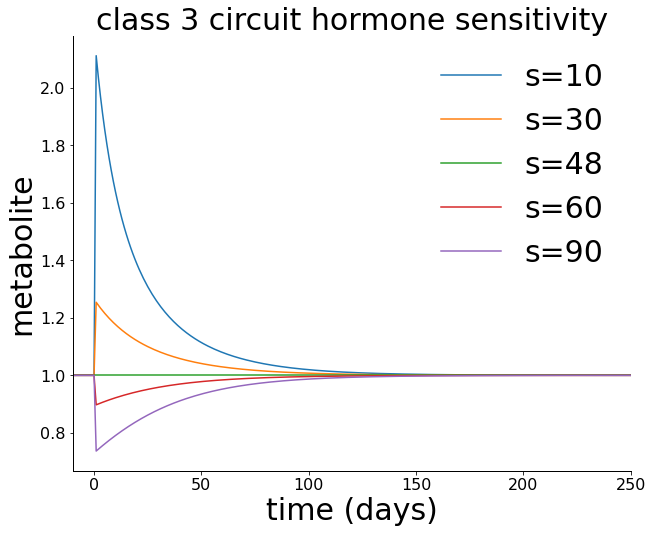

In [160]:
#CRH=np.zeros((1000,5))
#ACTH=np.zeros((1000,5))
#cortisol=np.zeros((1000,5))
#pituitary=np.zeros((1000,5))
#adrenal=np.zeros((1000,5))
#steroids=np.zeros((1000,5))
plt.figure(figsize=(10,8))
for i,alp in enumerate([10,30,48,60,90]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(3)
    #plt.figure()
    sol_slow_a2=odeint(lambda y,t: class_3_param_a2(y,t,a2_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    #CRH[:,i]=sol_weaning[:,0]
    #ACTH[:,i]=sol_weaning[:,1]
    #cortisol[:,i]=sol_weaning[:,2]
    #pituitary[:,i]=sol_weaning[:,3]
    #adrenal[:,i]=sol_weaning[:,4]
    #steroids[:,i]=sol_weaning[:,5]
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_a2[:,0]),linewidth=1.5)
    #plt.legend(['CRH','ACTH','Cortisol','pituitary','adrenal','steroid treatment'])
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('metabolite',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['s=10' , 's=30' , 's=48' , 's=60' , 's=90'], fontsize=30, frameon=False)
    plt.title('class 3 circuit hormone sensitivity', fontsize=30)
    plt.savefig("class 3_metabolite dynamics with different values of hormone sensitivity parameters.svg", transparent=True)

In [167]:
def class_3_param_b3(y,t,b3_=1,timescale='day',u_func = stress_input_long_3):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,_,bA_,bP_]=get5eqsparams(timescale)
    [x2_,x3_,A_]=y
    dy=np.empty(3)
    dy[0]= b2_*u_func(t)-a2_*x2_*x3_ #ACTH#metabolite
    dy[1]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[2]= A_*(bA_*x2_-aA_) #Adrenal cells#gland
    return dy

In [168]:
def stress_input_long_b3(t):
    if 0<t<=50:
        return 1
    if 50<t<150:
        return 3
    if t>150:
        return 1
    return 1

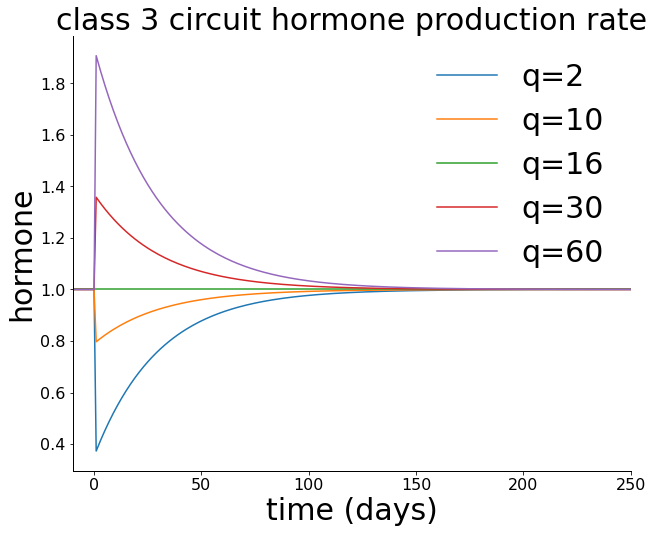

In [169]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([2,10,16,30,60]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(3)
    sol_slow_b3=odeint(lambda y,t: class_3_param_b3(y,t,b3_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_b3[:,1]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('hormone',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['q=2' , 'q=10' , 'q=16' , 'q=30' , 'q=60'], fontsize=30, frameon=False)
    plt.title('class 3 circuit hormone production rate', fontsize=30)
    plt.savefig("class 3 circuit hormone production rate.svg", transparent=True)

In [170]:
def class_3_param_a3(y,t,a3_=1,timescale='day',u_func = stress_input_long_3):
    [a1_,a2_,_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x2_,x3_,A_]=y
    dy=np.empty(3)
    dy[0]= b2_*u_func(t)-a2_*x2_*x3_ #ACTH#metabolite
    dy[1]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[2]= A_*(bA_*x2_-aA_) #Adrenal cells#gland
    return dy

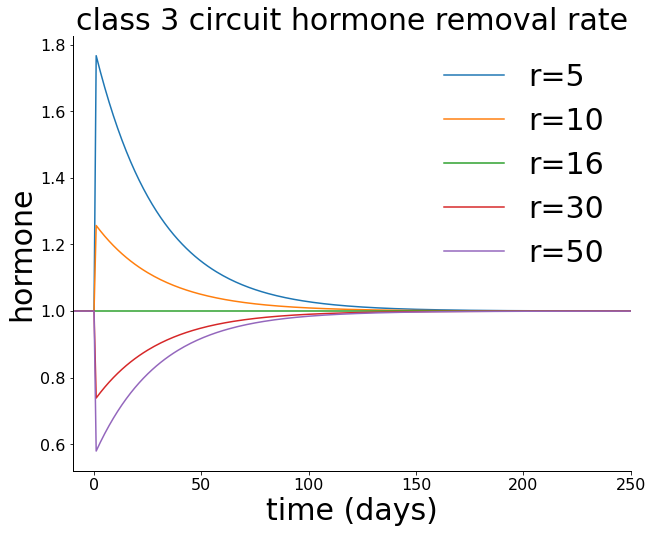

In [171]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([5,10,16,30,50]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(3)
    sol_slow_a3=odeint(lambda y,t: class_3_param_a3(y,t,a3_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_a3[:,1]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('hormone',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['r=5' , 'r=10' , 'r=16' , 'r=30' , 'r=50'], fontsize=30, frameon=False)
    plt.title('class 3 circuit hormone removal rate', fontsize=30)
    plt.savefig("class 3 circuit hormone removal rate.svg", transparent=True)

In [172]:
########class 4##########

In [173]:
def class_4_param_a2(y,t,a2_=1,timescale='day',u_func = lambda t:1):
    [a1_,_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x2_,x3_,P_,A_]=y
    dy=np.empty(4)
    #dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[0]= (b2_*P_*u_func(t))/x3_-a2_*x2_ #ACTH#hormone
    dy[1]= b3_*x2_*A_-a3_*x3_ #Cortisol#metabolite
    dy[2]= 0   
    dy[3]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy


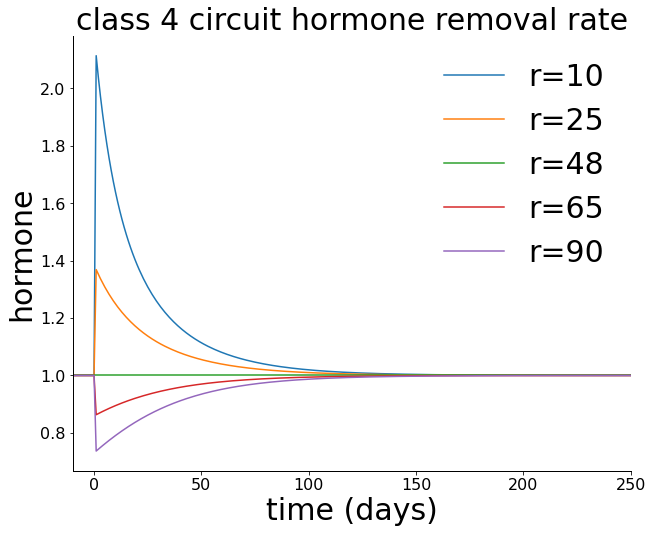

In [174]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([10,25,48,65,90]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(4)
    sol_slow_class4_a2=odeint(lambda y,t: class_4_param_a2(y,t,a2_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_class4_a2[:,0]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('hormone',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['r=10' , 'r=25' , 'r=48' , 'r=65' , 'r=90'], fontsize=30, frameon=False)
    plt.title('class 4 circuit hormone removal rate', fontsize=30)
    plt.savefig("class 4 circuit hormone removal rate.svg", transparent=True)

In [175]:
def class_4_param_b3(y,t,b3_=1,timescale='day',u_func = lambda t:1):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,_,bA_,bP_]=get5eqsparams(timescale)
    [x2_,x3_,P_,A_]=y
    dy=np.empty(4)
    #dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[0]= (b2_*P_*u_func(t))/x3_-a2_*x2_ #ACTH#hormone
    dy[1]= b3_*x2_*A_-a3_*x3_ #Cortisol#metabolite
    dy[2]= 0   
    dy[3]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

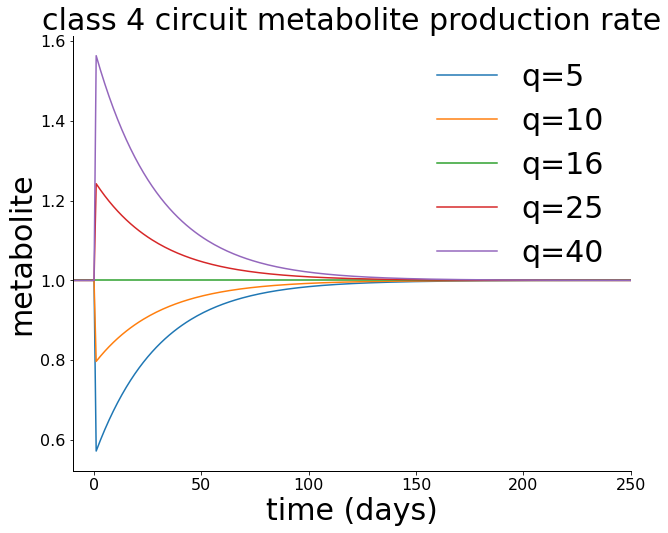

In [176]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([5,10,16,25,40]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(4)
    sol_slow_class4_b3=odeint(lambda y,t: class_4_param_b3(y,t,b3_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_class4_b3[:,1]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('metabolite',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['q=5' , 'q=10' , 'q=16' , 'q=25' , 'q=40'], fontsize=30, frameon=False)
    plt.title('class 4 circuit metabolite production rate', fontsize=30)
    plt.savefig("class 4 circuit metabolite production rate.svg", transparent=True)

In [177]:
def class_4_param_a3(y,t,a3_=1,timescale='day',u_func = lambda t:1):
    [a1_,a2_,_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x2_,x3_,P_,A_]=y
    dy=np.empty(4)
    #dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[0]= (b2_*P_*u_func(t))/x3_-a2_*x2_ #ACTH#hormone
    dy[1]= b3_*x2_*A_-a3_*x3_ #Cortisol#metabolite
    dy[2]= 0   
    dy[3]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

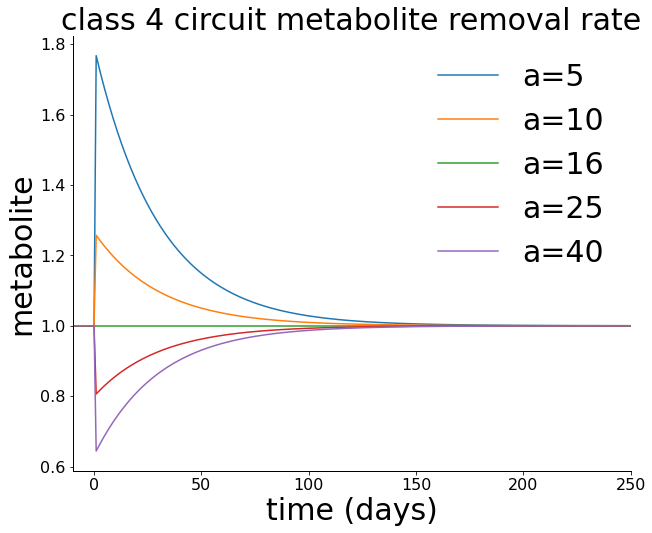

In [179]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([5,10,16,25,40]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(4)
    sol_slow_class4_a3=odeint(lambda y,t: class_4_param_a3(y,t,a3_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_class4_a3[:,1]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('metabolite',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['a=5' , 'a=10' , 'a=16' , 'a=25' , 'a=40'], fontsize=30, frameon=False)
    plt.title('class 4 circuit metabolite removal rate', fontsize=30)
    plt.savefig("class 4 circuit metabolite removal rate.svg", transparent=True)

In [180]:
#######class 5############

In [181]:
def class_5_param_b1(y,t,b1_=1,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    [a1_,a2_,a3_,aA_,aP_,_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_*(1/(1+(x3_/kgr(t))**n(t)))-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[3]= P_*(bP_*x1_-aP_)#Pituitary cells   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

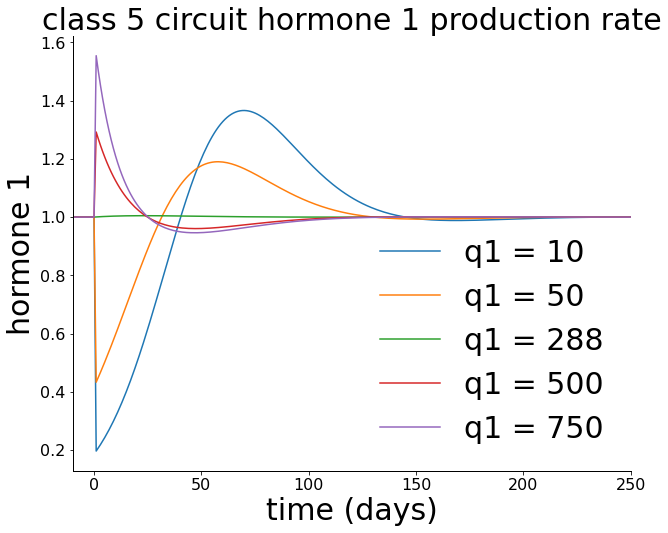

In [182]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([10,50,288,500,750]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(5)
    sol_slow_class5_b1=odeint(lambda y,t: class_5_param_b1(y,t,b1_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_class5_b1[:,0]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('hormone 1',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['q1 = 10' , 'q1 = 50' , 'q1 = 288' , 'q1 = 500' , 'q1 = 750'], fontsize=30, frameon=False)
    plt.title('class 5 circuit hormone 1 production rate', fontsize=30)
    plt.savefig('class 5 circuit hormone 1 production rate.svg', transparent=True)

In [184]:
def class_5_param_a1(y,t,a1_=1,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    [_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_*(1/(1+(x3_/kgr(t))**n(t)))-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[3]= P_*(bP_*x1_-aP_)#Pituitary cells   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

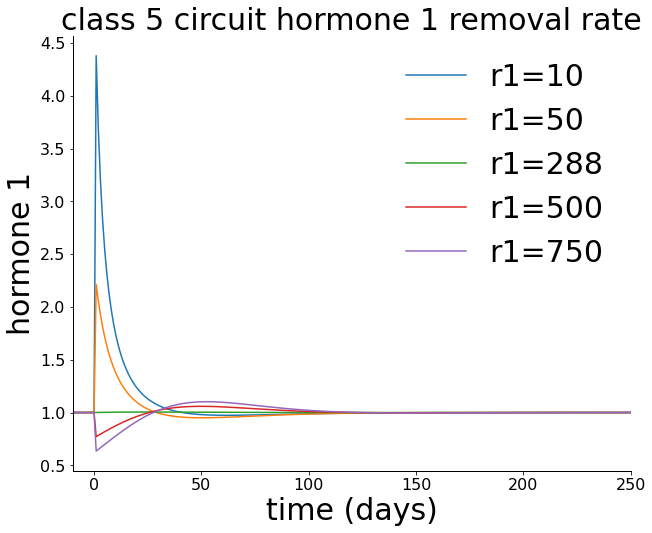

In [185]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([10,50,288,500,750]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(5)
    sol_slow_class5_a1=odeint(lambda y,t: class_5_param_a1(y,t,a1_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_class5_a1[:,0]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('hormone 1',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['r1=10' , 'r1=50' , 'r1=288' , 'r1=500' , 'r1=750'], fontsize=30, frameon=False)
    plt.title('class 5 circuit hormone 1 removal rate', fontsize=30)
    plt.savefig("class 5 circuit hormone 1 removal rate.svg", transparent=True)

In [186]:
def class_5_param_b2(y,t,b2_=1,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    [a1_,a2_,a3_,aA_,aP_,b1_,_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_*(1/(1+(x3_/kgr(t))**n(t)))-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[3]= P_*(bP_*x1_-aP_)#Pituitary cells   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

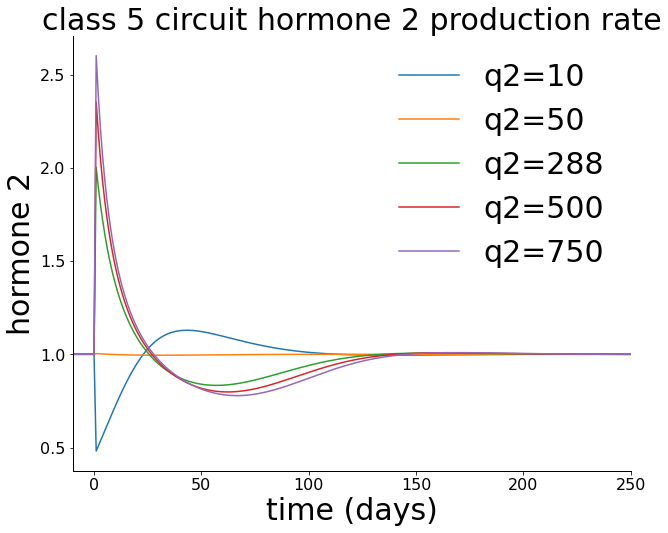

In [189]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([10,50,288,500,750]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(5)
    sol_slow_class5_b2=odeint(lambda y,t: class_5_param_b2(y,t,b2_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_class5_b2[:,1]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('hormone 2',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['q2=10' , 'q2=50' , 'q2=288' , 'q2=500' , 'q2=750'], fontsize=30, frameon=False)
    plt.title('class 5 circuit hormone 2 production rate', fontsize=30)
    plt.savefig("class 5 circuit hormone 2 production rate.svg", transparent=True)

In [191]:
def class_5_param_a2(y,t,a2_=1,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    [a1_,_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_*(1/(1+(x3_/kgr(t))**n(t)))-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[3]= P_*(bP_*x1_-aP_)#Pituitary cells   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

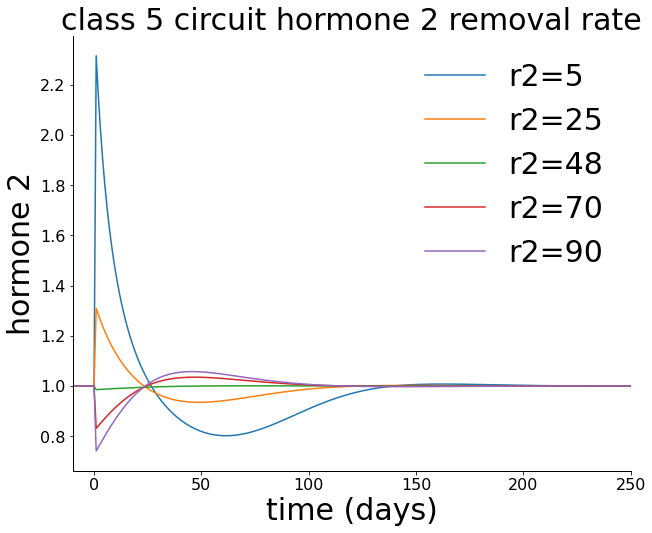

In [208]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([5,25,48,70,90]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(5)
    sol_slow_class5_a2=odeint(lambda y,t: class_5_param_a2(y,t,a2_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_class5_a2[:,1]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('hormone 2',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['r2=5' , 'r2=25' , 'r2=48' , 'r2=70' , 'r2=90'], fontsize=30, frameon=False)
    plt.title('class 5 circuit hormone 2 removal rate', fontsize=30)
    plt.savefig("class 5 circuit hormone 2 removal rate.svg", transparent=True)

In [209]:
def class_5_param_b3(y,t,b3_=1,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_*(1/(1+(x3_/kgr(t))**n(t)))-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[3]= P_*(bP_*x1_-aP_)#Pituitary cells   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

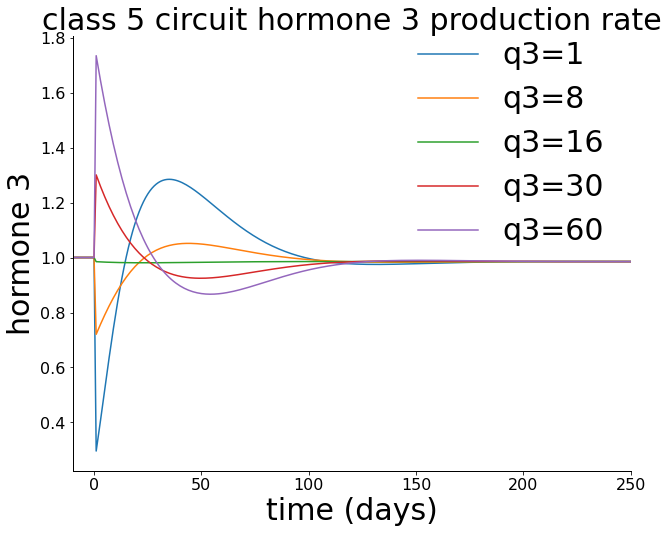

In [220]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([1,8,16,30,60]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(5)
    sol_slow_class5_b3=odeint(lambda y,t: class_5_param_b3(y,t,b3_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_class5_b3[:,2]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('hormone 3',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['q3=1' , 'q3=8' , 'q3=16' , 'q3=30' , 'q3=60'], fontsize=30, frameon=False, loc='upper right', bbox_to_anchor=(1.0, 1.05))
    plt.title('class 5 circuit hormone 3 production rate', fontsize=30)
    plt.savefig("class 5 circuit hormone 3 production rate.svg", transparent=True)

In [211]:
def class_5_param_a3(y,t,a3_=1,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    [a1_,a2_,_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_*(1/(1+(x3_/kgr(t))**n(t)))-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[3]= P_*(bP_*x1_-aP_)#Pituitary cells   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

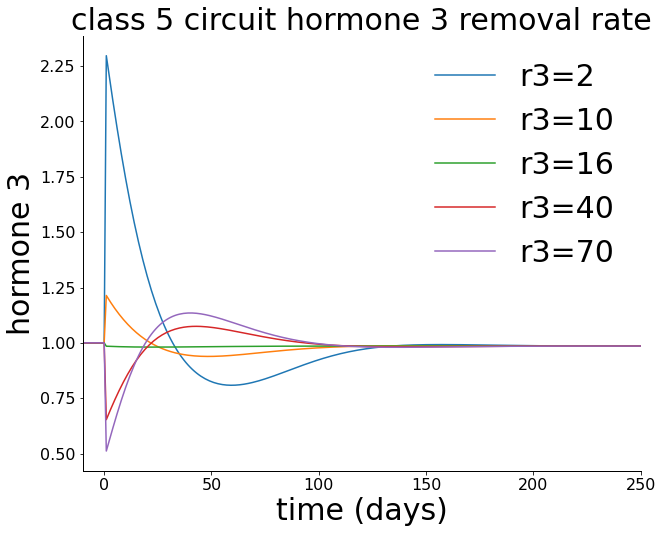

In [212]:
plt.figure(figsize=(10,8))
for i,alp in enumerate([2,10,16,40,70]):
    t_recovery=np.linspace(0, 1000, 1000)
    int_conditions= np.ones(5)
    sol_slow_class5_a3=odeint(lambda y,t: class_5_param_a3(y,t,a3_=alp,timescale='day',u_func = lambda t:1),int_conditions,t_recovery)
    plt.plot([-10,0]+list(t_recovery),[1,1]+list(sol_slow_class5_a3[:,2]),linewidth=1.5)
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(-10,250)
    plt.xlabel('time (days)',fontsize=30)
    plt.ylabel('hormone 3',fontsize=30)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.legend(['r3=2' , 'r3=10' , 'r3=16' , 'r3=40' , 'r3=70'], fontsize=30, frameon=False)
    plt.title('class 5 circuit hormone 3 removal rate', fontsize=30)
    plt.savefig("class 5 circuit hormone 3 removal rate.svg", transparent=True)